# Wildfire Prediction

## Table of content

- Read data

- Exploratory data analysis
    - Data structure
    - Class balance
    - FWI distribution
    - Fire Class by time period

- ML Model Training
    - Train/test split
    - Models
        - Random Forest
        - Logistic Regression
    - Hyperparameter Tunning #TODO
        -  Randomized Search #TODO
    - CrossValidation
        - F1 Score
        - AUC
        - Classification Report
    - Testing
        - #TODO

## Read data

### Libraries

In [1]:
import utils.datasets_utils as du
import ml_models.ml_utils as mu
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import os 
from scripts.s00_set_parameters import PARAMETERS
from typing import Any


### Load data

In [78]:
# Base path/location of data
path_base = PARAMETERS['DATA_DIR']/"MLInputs"
# Input files to load
files_to_load = {"resnet_default_weights":  "2026-07-12_ml_input.csv",
                 "resnet_layer4_finetuned": "2026-07-19_ml_input_layer4_finetuned.csv"}
# Generate full paths 
files_to_load = {k: os.path.join(path_base, v) for (k, v) in files_to_load.items()}
# Spefic data types requirements
string_cols = {"composite_key": "string", "composite_key_y": "string", "bridge_composite_key_y": "string"}
date_cols   = ["date_y", "date"]
# Load data 
df_resnet_default   = pd.read_csv(files_to_load["resnet_default_weights"], dtype  = string_cols, parse_dates=date_cols) #type: ignore
df_resnet_finetuned = pd.read_csv(files_to_load["resnet_layer4_finetuned"], dtype = string_cols, parse_dates=date_cols) #type: ignore


## Exploratory data analysis

### Data structure

Ensure that the structure of both data frames is the same. The only difference should be the values in the feature columns - everything else should be equal

In [79]:
# Validate structure is the same
print("Structure Validation: ")
print(f"- Columns match:    {df_resnet_finetuned.columns.equals(df_resnet_default.columns)}")
print(f"- Data types match: {df_resnet_finetuned.dtypes.equals(df_resnet_default.dtypes)}")
print(f"- Data Shape match: {df_resnet_finetuned.shape == df_resnet_default.shape}")

# Validate that the only data differences are found in feature columns, all other data points should be the same between data frames 
feat_cols               = [c for c in df_resnet_default.columns if re.search("^feat_", c)]
df_minus_feat_default   = df_resnet_default.drop(columns=feat_cols)
df_minus_feat_finetuned = df_resnet_finetuned.drop(columns=feat_cols)
# Validate data matches
print("\nData Validation:")
try:
    pd.testing.assert_frame_equal(df_minus_feat_default,  df_minus_feat_finetuned)
    print("- Non-feature data match: True")
except AssertionError as e:
    print("- Non-feature data match: False")
    print(e)

Structure Validation: 
- Columns match:    True
- Data types match: True
- Data Shape match: True

Data Validation:
- Non-feature data match: True


Columns and data types for reference:

In [80]:
col_names = df_resnet_default.columns
for pos, dt in enumerate(df_resnet_default.dtypes):
    print(f"{col_names[pos]}: \t\t\t{dt}")
  

composite_key_y: 			string
grid_id_y: 			int64
sample_type_y: 			str
date_y: 			datetime64[us]
fire_lbl_y: 			bool
bridge_composite_key_y: 			string
grid_id: 			float64
x_coord: 			float64
y_coord: 			float64
geometry: 			str
date: 			datetime64[us]
viirs_n: 			float64
frp_max: 			float64
frp_mean: 			float64
fire_lbl: 			bool
fwi_max: 			float64
fwi_mean: 			float64
composite_key: 			string
feat_000: 			float64
feat_001: 			float64
feat_002: 			float64
feat_003: 			float64
feat_004: 			float64
feat_005: 			float64
feat_006: 			float64
feat_007: 			float64
feat_008: 			float64
feat_009: 			float64
feat_010: 			float64
feat_011: 			float64
feat_012: 			float64
feat_013: 			float64
feat_014: 			float64
feat_015: 			float64
feat_016: 			float64
feat_017: 			float64
feat_018: 			float64
feat_019: 			float64
feat_020: 			float64
feat_021: 			float64
feat_022: 			float64
feat_023: 			float64
feat_024: 			float64
feat_025: 			float64
feat_026: 			float64
feat_027: 			float64
feat_028: 			floa

The full dataset contains the columns below. All the columns that end with suffix `y` refer to be values to be predicted. These are the values that the model needs to predict. The rest of the columns contain the data to train the model. The training data (non `y` columns) are from a t-1 from value to predict. 

In [81]:
# Check assumptions for all datasets
for _, row in df_resnet_default.iterrows():
    row: Any
    days_diff = (row.date_y - row.date).days
    if days_diff != 1:
        print('❌ Date assumption of t-1 not met!')
print(f"✅ t-1 assumption validated\n  [{df_resnet_default.shape[0]} rows checked]")

✅ t-1 assumption validated
  [38204 rows checked]


### Class balance

The sampling procedure implemented a 2:1 no-fire to fire ratio when selecting the samples. The reason of this is that no-fire events are much more common than fire events. However, using the real distribution would have produced an extremely imbalanced dataset. To mitigate this, a 2:1 ratio was implemented to maintain the frequency property but reducing the class imbalance to a more manageable state, as done by previous studies. 

The complete details of the sampling procedure are in:
- Functions: `src/sampling/sampling_functions.py` 
- Pipeline: `src/pipelines/sampling_pipeline.py`

In [82]:
print("=== Class Balance ===")
print(df_resnet_default['fire_lbl_y'].value_counts(normalize=True))



=== Class Balance ===
fire_lbl_y
False    0.614412
True     0.385588
Name: proportion, dtype: float64


### FWI Distribution

#### Tabular

The class imbalance in the predictor variable is evident, with only 1,816 fire observations vs 36,388 no-fire observations (see `df_fwi_descriptives` below).

The descriptive statistics show that the fire class, overall, has higher FWI values than the no fire, with the median of fire observations (*M = 2.55*) almost 3 times higher than the no-fire (*M = 0.91*) counterpart. It is worth nothing, however, that the max value of no-fire is greater than the fire (more than 2sd above the max). This is the case for 7/36388 of the no-fire observations, which indicates these are rare observations (See FWI - BLOCK 2).

In [83]:
# FWI - BLOCK 1 - Descriptives
df_fwi_descriptives = df_resnet_default[['fwi_mean', 'fire_lbl']].groupby('fire_lbl').describe()
df_fwi_descriptives

fwi_mean                                                        \
            count      mean       std           min       25%       50%   
fire_lbl                                                                  
False     36388.0  3.620400  5.880850  1.721512e-09  0.257813  0.914331   
True       1816.0  5.732212  7.466659  1.724128e-09  0.690369  2.551709   

                               
               75%        max  
fire_lbl                       
False     4.617249  68.532227  
True      7.889746  50.774902

In [84]:
# FWI - BLOCK 2 - FWI value max review
# Count of no fire observations above the max of Fire
fwi_fire_lbl_max = df_fwi_descriptives.loc[True, ("fwi_mean", "max")]
df_resnet_default[ (df_resnet_default['fire_lbl'] == False) & (df_resnet_default['fwi_mean'] > fwi_fire_lbl_max)].shape[0]

7

#### Visualisation

To visually compare the distribution of FWI values between fire and no-fire observations a histogram of raw counts is not appropiate given the large class imbalance. The dataset contains many more no-fire than fire observations, therefore, the no-fire class dominates the the histogram, making it difficult to compare the two classes

Text(0.5, 1.0, 'Distribution of Fire Weather Index')

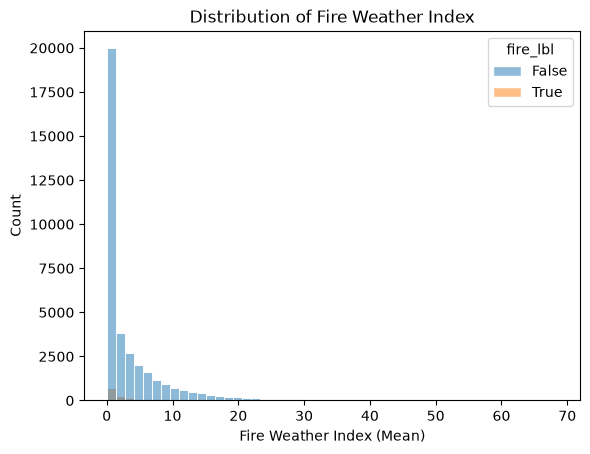

In [85]:
sns.histplot(data=df_resnet_default,
             x="fwi_mean",
             hue = 'fire_lbl',
             bins = 50,
             edgecolor = "white")
plt.xlabel("Fire Weather Index (Mean)")
plt.ylabel("Count")
plt.title("Distribution of Fire Weather Index")

Instead, comparing the **distribution** of each class provides a more informative visualisation of the FWI data. By normalising each class independently, the underlying distributions can be compared without being obscured by the class imbalance, making the class differences easier to observe.

The `common_norm` parameter is set to `False` to ensure that each class is normalised independently. By default, the histogram is normalised across both classes, meaning that the combined area under the two distributions would sum to 1, which makes visual comparisons hard to communicate as the majority class would overtake the visual space. Instead, with `common_norm` set to `False` the function normalises each class separately, so the area under each class distribution sums to 1. This allows to visually compare the fire and no-fire observations distributions independently of class imbalance. 


<Axes: xlabel='fwi_mean', ylabel='Density'>

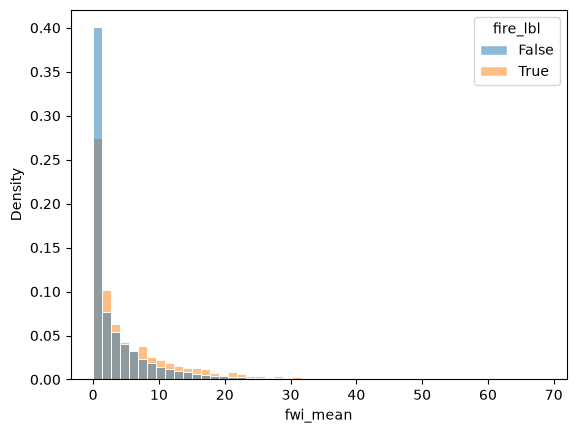

In [86]:
sns.histplot(data = df_resnet_default,
             x = "fwi_mean",
             hue = "fire_lbl",
             bins = 50,
             stat = "density",
             common_norm = False,
             edgecolor = "white")

#### Data by Class over time period

In [87]:
# Helper function to create stacked bar chart to show split by temporal bins and fire, no-fire observations
def summarise_obs_by_time(df_in:pd.DataFrame, temporal_split = 'year') -> dict:
    barchart_data = {}
    for row in df_in.itertuples():
        row: Any
        temporal_string = du.get_temporal_label(row.date, temporal_split)
        fire_lbl        = row.fire_lbl

        if temporal_string not in barchart_data:
            barchart_data[temporal_string] = {"fire": 0, "no_fire": 0}

        if fire_lbl:
            barchart_data[temporal_string]["fire"] += 1
        else:
            barchart_data[temporal_string]["no_fire"] += 1
    return barchart_data


Review how many observations per year

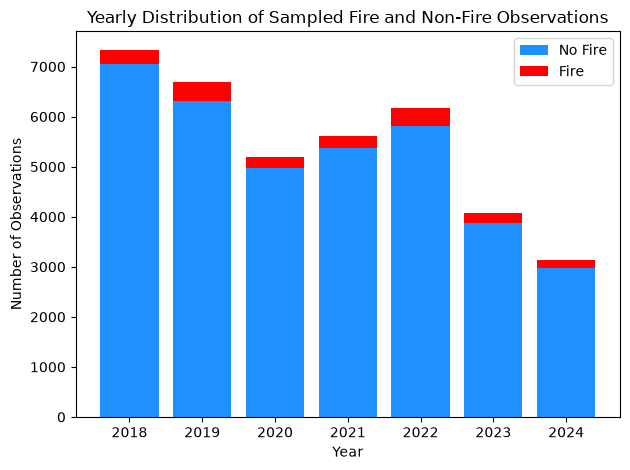

In [88]:
df_plot = pd.DataFrame(summarise_obs_by_time(df_resnet_default, 'year'))
plt.bar(df_plot.columns,
        df_plot.loc['no_fire'],
        color = 'dodgerblue',
        label="No Fire")

plt.bar(df_plot.columns,
        df_plot.loc['fire'],
        bottom = df_plot.loc['no_fire'],
        color = 'red',
        label="Fire")


plt.xlabel("Year")
plt.ylabel("Number of Observations")
plt.title("Yearly Distribution of Sampled Fire and Non-Fire Observations")

plt.legend()
plt.tight_layout()
plt.show()

## ML Model Training

### Initialise Models

In [89]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

random_state = 42
class_weight = 'balanced'

# Initialise models
models = {'random_forest': RandomForestClassifier(random_state=random_state, class_weight=class_weight,n_jobs =1),
          'logistic_reg':  Pipeline([("scaler", StandardScaler()),
                                        ("lr", LogisticRegression(class_weight=class_weight,
                                                                  random_state=random_state,
                                                                  max_iter = 1000))])
}


### Train/Test split

In [90]:
# =============
# SPLIT DATA
# =============
# reserve the test data, do not use in crossvalidation process
df_train, df_test       = mu.train_test_temporal_split(df_resnet_default)
df_train_ft, df_test_ft =  mu.train_test_temporal_split(df_resnet_finetuned)

# REMINDER - All feature column names are already saved in:
feat_cols = feat_cols

# Validate that the temporal split for both datasets is the same apart from Sentinel-2 data
# This allows for a single set of y values to be used instead of duplicating work
validation_pairs = [("Training", df_train, df_train_ft),
                    ("Test", df_test, df_test_ft)]

for name, df_a, df_b in validation_pairs:
    print(f"\n{name} data validation:")
    try:
        pd.testing.assert_frame_equal(df_a.drop(columns=feat_cols), df_b.drop(columns=feat_cols))
        print("- Non-feature data match: True")

    except AssertionError as e:
        print("- Non-feature data match: False")
        print(e)



ℹ️  INFO Train/Test split based on date
Requested train size : 0.7000
Actual train size    : 0.7037
Actual test size     : 0.2963

ℹ️  INFO Train/Test split based on date
Requested train size : 0.7000
Actual train size    : 0.7037
Actual test size     : 0.2963

Training data validation:
- Non-feature data match: True

Test data validation:
- Non-feature data match: True


Once confirmed that data is equal for test and train datasets (except for Sentinel-2 feature values), a single set of FWI and Y Values can be used across the training/testing process

In [91]:
# Hybrid Model columns
hybrid_cols = feat_cols + ['fwi_mean']
# =============
# Y VALUES
# =============
# Split Y labels by default and training to ensure correctness and consitency
y_train = df_train["fire_lbl_y"]
y_test  = df_test["fire_lbl_y"]

# =============
# X VALUES
# =============
# FWI can be taken from default or fine tuned, no difference in data as shown in code blocks above
X_train_fwi = df_train.loc[:, ["fwi_mean"]]
X_test_fwi  = df_test.loc[:,  ["fwi_mean"]]

# Sentinel-2 Default ResNet18 Weights
X_train_sent2_def = df_train.loc[:, feat_cols]
X_test_sent2_def  = df_test.loc[:, feat_cols]
# Hybrid, Sentinel-2 Default ResNet18 Weights
X_train_hybrid_def = df_train.loc[:, hybrid_cols]
X_test_hybrid_def  = df_test.loc[:, hybrid_cols]

# Sentinel-2 fineTuned ResNet18 Weights
X_train_sent2_ft = df_train_ft.loc[:, feat_cols]
X_test_sent2_ft  = df_test_ft.loc[:, feat_cols]
# Hybrid, Sentinel-2 fineTuned ResNet18 Weights
X_train_hybrid_ft = df_train_ft.loc[:, hybrid_cols]
X_test_hybrid_ft  = df_test_ft.loc[:, hybrid_cols]

# Combine predictor data into a single dictionary
training_predictor_data = {'fwi': X_train_fwi,
                           
                           'sentinel_default': X_train_sent2_def,
                           'hybrid_default'  : X_train_hybrid_def,

                           'sentinel_fineTuned': X_train_sent2_ft,
                           'hybrid_fineTuned'  : X_train_hybrid_ft}



### Train models

Use CrossValidation to train Random Forest and Logistic Regression on the various datasets:
- FWI
- Sentinel-2 with Default Resnet 18 weights
- Sentinel-2 with fine tuned Resnet 19 weights

**Note:**

No hyperparameter tuning is implemented yet. this is next step of the project

In [92]:
# Initialise summary results object
summary_results = []
# Loop over each required dataset for training
for d_name, d in training_predictor_data.items():
    # Loop over each model 
    for m_name, model in models.items():
        model_name_i = f"{m_name}_{d_name}"
        print(f"\n\t\t >>>> Processing: [{model_name_i}] <<<<")
        m_trained = mu.model_crossvalidation(model      = model,
                                             X          = d,
                                             y          =  y_train,
                                             model_name = model_name_i,
                                             n_splits   = 8,
                                             verbose    = False )
        summary_results.append({'model': model_name_i,
                                'mean_f1':  m_trained[model_name_i]["F1 Mean Score"],
                                'mean_auc': m_trained[model_name_i]["AUC Mean Score"],
                                'mean_classification_report': m_trained[model_name_i]["Average Classification Report"]})


		 >>>> Processing: [random_forest_fwi] <<<<
Model name: random_forest_fwi. Fold 7
========== Model: random_forest_fwi ==========
Mean F1 Score: 0.420
Mean AUC Score: 0.541
Total folds: 8
Average Class Report
              precision    recall  f1-score      support
False          0.652238  0.633199  0.638713  1858.125000
True           0.414861  0.431845  0.419807  1128.875000
accuracy       0.572983  0.572983  0.572983     0.572983
macro avg      0.533549  0.532522  0.529260  2987.000000
weighted avg   0.576584  0.572983  0.570995  2987.000000

		 >>>> Processing: [logistic_reg_fwi] <<<<
Model name: logistic_reg_fwi. Fold 7
========== Model: logistic_reg_fwi ==========
Mean F1 Score: 0.387
Mean AUC Score: 0.635
Total folds: 8
Average Class Report
              precision    recall  f1-score      support
False          0.686593  0.749428  0.697586  1858.125000
True           0.493854  0.377860  0.387359  1128.875000
accuracy       0.642325  0.642325  0.642325     0.642325
macro avg    

*This is basic commentary on the initial findings of this exploratory excercise. This is by no means the final view and intepretation of results*

The highest mean F1-score was achieved by the **Logistic Regression, hybrid, Fine Tuned model** *Mean F1 = 0.517*. 

Table 1 suggests that the **logistic regression models** achieved higher F1 scores than the **random forest models**, and that Satelite images (sentinel-2 data), in addition to FWI, achieved the best performance. For **Logistic Regression models**, Satellite images alone outperformed FWI, but the hybrid model perform better than either stand alone model. 

Table 2 shows the models arranged by mean AUC scores. In contrast to the F1 results, the **Random Forest, Hybrid fine tuned model** had the highest *Mean AUC = 0.65* score. However, as with F1 scores, the **hybrid fine tuned models** performed better overall. This suggests that the combination of Satellite + Tabular data appears to provide the best results in this preeliminary test, and that fine tuning appears to improves the quality of the features extracted. 

In [ ]:
# Consolidate results into single data frame
cols_of_interest = ['model', 'mean_f1','mean_auc']
print("Table 1. Results sorted by F1 Mean Score ")
df_results = pd.DataFrame(summary_results)

df_by_f1 = df_results.loc[:, cols_of_interest].sort_values("mean_f1", ascending=False)
print(df_by_f1)

print("-------")
print("Table 2. Results sorted by AUC Mean Score ")
df_by_auc = df_results.loc[:, cols_of_interest].sort_values("mean_auc", ascending=False)
print(df_by_auc)


Results sorted by F1 Mean Score 
                              model   mean_f1  mean_auc
9     logistic_reg_hybrid_fineTuned  0.517139  0.645247
7   logistic_reg_sentinel_fineTuned  0.508821  0.610868
3     logistic_reg_sentinel_default  0.464143  0.557159
5       logistic_reg_hybrid_default  0.462959  0.590855
8    random_forest_hybrid_fineTuned  0.455677  0.650571
0                 random_forest_fwi  0.419807  0.541091
6  random_forest_sentinel_fineTuned  0.413669  0.620439
4      random_forest_hybrid_default  0.390908  0.597909
1                  logistic_reg_fwi  0.387359  0.634948
2    random_forest_sentinel_default  0.377100  0.567680
-------
Results sorted by AUC Mean Score 
                              model   mean_f1  mean_auc
8    random_forest_hybrid_fineTuned  0.455677  0.650571
9     logistic_reg_hybrid_fineTuned  0.517139  0.645247
1                  logistic_reg_fwi  0.387359  0.634948
6  random_forest_sentinel_fineTuned  0.413669  0.620439
7   logistic_reg_sentinel_fin

The classification report below provides more detailed information about the model performance. 

Table 1 shows that Fire (`True`) class generally achieves lower precision and F-1 scores than the no Fire (`False`) class. This may be partly explained by the class imbalance, as having more `False` observations provide the model with more examples to learn from.  

For the **Hybrid Logistic Regression models**, the `False` class precision is consistently higher than recall. This value represents the proportion of correct No Fire predictions provided by the model, meaning that `False` predictions were generally correct (~.65-.72). However, the lower recall suggests that many actual `No fire` events were incorrectly labelled as Fire. This may indicate that the models might be more likely to classify some `No fire` as `Fire`, rather than accurately discriminating between the two classes.

This is consistent with the pattern shown for the `True` class, where precision is lower, meaning that when the model predicted `Fire`, a lower proportion of those predictions were actually fire events. However, the higer recall suggest that a greater proportion of the actual `Fire` observations were correctly identified. This might be expected given the class imbalance of the data.

The F1-Score is consistently lower for the Fire (`True`) class than for the `No fire` across all of the models shown on the two tables below. This suggests that accurately predicting fire is more challenging for the model. 

The model with the highest Mean F-1 Score (**F1 Score = 0.52**, `logistic_reg_hybrid_fineTuned`) had a higer Recall (0.57) than Precision (0.48) for the Fire (`True`) class. This means that the model identifies a greater proportion of actual Fire events at the expense of more false alarms. 

In the context of Wildfire Prediction, this might be desirable as the cost of failing to detect WildFires might be greater than investigating a False alarm. However, False alarms need to be managed as well, as too many False alarms may result in resources being misallocated, and might be made unavailable to respond to real Fire events.  

However, it is worth noting that these are preeliminary results, and performance might improve once hyperparameter tuning in implemented.

In [76]:
# Get the detailed results for the top 3 models for F1 Score
for model in df_by_f1['model'].head(3):
    report = df_results.loc[df_results['model'] == model, "mean_classification_report"].iloc[0] #type: ignore
    print(f"======= {model} ========")
    print(report)


======= logistic_reg_hybrid_fineTuned ========
              precision    recall  f1-score      support
False          0.715501  0.613228  0.648963  1858.125000
True           0.481627  0.574995  0.517139  1128.875000
accuracy       0.622238  0.622238  0.622238     0.622238
macro avg      0.598564  0.594112  0.583051  2987.000000
weighted avg   0.637095  0.622238  0.616387  2987.000000
======= logistic_reg_sentinel_fineTuned ========
              precision    recall  f1-score      support
False          0.693478  0.566510  0.621220  1858.125000
True           0.452451  0.585894  0.508821  1128.875000
accuracy       0.590475  0.590475  0.590475     0.590475
macro avg      0.572965  0.576202  0.565021  2987.000000
weighted avg   0.614802  0.590475  0.593574  2987.000000
======= logistic_reg_sentinel_default ========
              precision    recall  f1-score      support
False          0.662747  0.531661  0.584215  1858.125000
True           0.411500  0.541962  0.464143  1128.875000
ac

In [77]:
# Get the detailed results for the top 3 models for AUC Score
for model in df_by_auc['model'].head(3):
    report = df_results.loc[df_results['model'] == model, "mean_classification_report"].iloc[0] # type: ignore
    print(f"======= {model} ========")
    print(report)

======= random_forest_hybrid_fineTuned ========
              precision    recall  f1-score      support
False          0.684613  0.810639  0.741740  1858.125000
True           0.561324  0.386653  0.455677  1128.875000
accuracy       0.660947  0.660947  0.660947     0.660947
macro avg      0.622969  0.598646  0.598709  2987.000000
weighted avg   0.649007  0.660947  0.644933  2987.000000
======= logistic_reg_hybrid_fineTuned ========
              precision    recall  f1-score      support
False          0.715501  0.613228  0.648963  1858.125000
True           0.481627  0.574995  0.517139  1128.875000
accuracy       0.622238  0.622238  0.622238     0.622238
macro avg      0.598564  0.594112  0.583051  2987.000000
weighted avg   0.637095  0.622238  0.616387  2987.000000
======= logistic_reg_fwi ========
              precision    recall  f1-score      support
False          0.686593  0.749428  0.697586  1858.125000
True           0.493854  0.377860  0.387359  1128.875000
accuracy       0